# Custom Layers: ExponentialLayer, MyDense, AddGaussianNoise, LayerNormalization

# Setup

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Custom Layer: ExponentialLayer

In [24]:
# ✅ Custom Layer: ExponentialLayer
class ExponentialLayer(layers.Layer):
    def call(self, inputs):
        return tf.exp(inputs)

# Custom Layer: MyDense

In [25]:
class MyDense(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.kernel = self.add_weight(name="kernel", shape=(int(input_shape[-1]), self.units), initializer="glorot_uniform")
        self.bias = self.add_weight(name="bias", shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        return tf.matmul(inputs, self.kernel) + self.bias

# Custom Layer: AddGaussianNoise

In [26]:
# ✅ Custom Layer: AddGaussianNoise
class AddGaussianNoise(layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=False):
        if training:
            noise = tf.random.normal(shape=tf.shape(inputs), mean=0.0, stddev=self.stddev)
            return inputs + noise
        return inputs

# Custom Layer: Simple LayerNormalization

In [27]:
# ✅ Custom Layer: Simple LayerNormalization
class SimpleLayerNormalization(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(shape=input_shape[-1:], initializer="ones", trainable=True)
        self.beta = self.add_weight(shape=input_shape[-1:], initializer="zeros", trainable=True)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        norm_inputs = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * norm_inputs + self.beta

# Load Dataset

In [28]:
# ✅ Load Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Model with Custom Layers

In [29]:
# ✅ Model with Custom Layers
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    AddGaussianNoise(0.1),
    MyDense(128),
    layers.Activation('relu'),
    SimpleLayerNormalization(),
    MyDense(64),
    layers.Activation('relu'),
    ExponentialLayer(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Model

In [30]:
# ✅ Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test), verbose=2)

Epoch 1/5
938/938 - 9s - 9ms/step - accuracy: 0.8057 - loss: 0.5462 - val_accuracy: 0.8319 - val_loss: 0.4633
Epoch 2/5
938/938 - 10s - 11ms/step - accuracy: 0.8525 - loss: 0.4018 - val_accuracy: 0.8596 - val_loss: 0.3871
Epoch 3/5
938/938 - 6s - 6ms/step - accuracy: 0.8647 - loss: 0.3671 - val_accuracy: 0.8594 - val_loss: 0.3931
Epoch 4/5
938/938 - 7s - 7ms/step - accuracy: 0.8717 - loss: 0.3448 - val_accuracy: 0.8677 - val_loss: 0.3675
Epoch 5/5
938/938 - 5s - 6ms/step - accuracy: 0.8778 - loss: 0.3272 - val_accuracy: 0.8536 - val_loss: 0.3935


# Results Plot

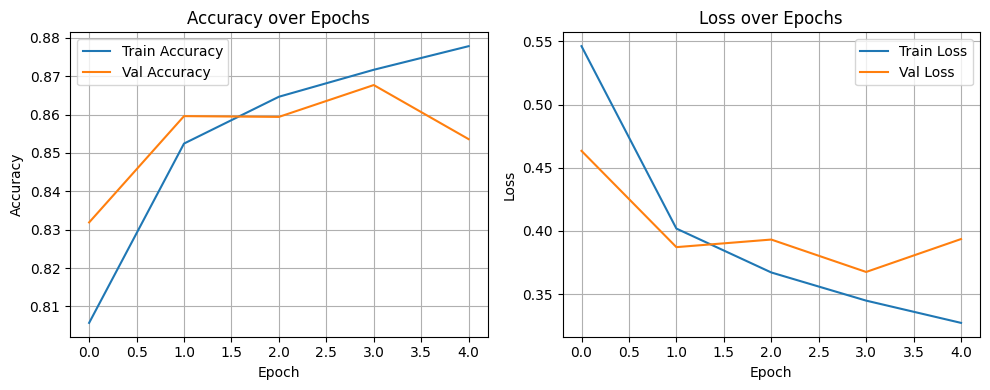

✅ Training with custom layers completed.


In [31]:
# ✅ Plot Results
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("✅ Training with custom layers completed.")

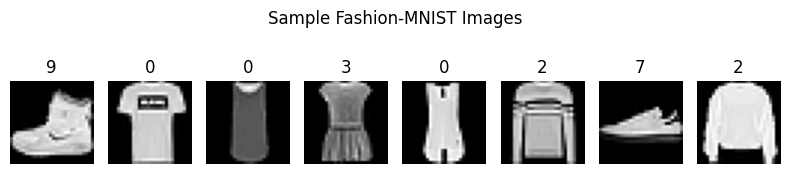

In [32]:
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()